In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import solve_banded
import h5py

## Fixed Zeta

In [19]:

#fixed zeta
Lk = 20    
T = 20
Nk = 10000   
Nt = 10000
zeta = 0.01
dk = Lk / (Nk)  
dt = T / Nt       

E = np.zeros((Nt, Nk))
k = np.linspace(dk+0.5, Lk, Nk)  

count = 0
for ki in k:
    if ki < 1:
        E[0,count] = ki**4
    elif ki<10:
        E[0,count] = ki**(-1)
    elif ki>= 10:
        E[0,count] =  (4.64)*ki**(-5/3)
    count+=1


for ti in range(0, Nt-1):
    for ki in range(0, Nk):
        if ki == 0:
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki]) / (0.5*dk) - (4 / k[ki]) * E[ti, ki])
        elif 0<ki<Nk-1:
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki-1]) / dk - (4 / k[ki]) * E[ti, ki])
        elif ki == Nk-1:
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki] - E[ti, ki-1]) / (0.5*dk) - (4 / k[ki]) * E[ti, ki])


k_max = []
for E_i in E:
    k_max.append(k[np.argmax(E_i)])
t_ff = []
for i in range(len(E)):
    t_ff.append( np.pi * i / (2 * np.sqrt(2) * np.arccos( 1/ k_max[i])))


times = [0,5,10,15]
timesp = ["t = "+ str(t_ff[int(time/dt)]) for time in times]
slopes = np.zeros((4,2))

tick = 0
for time in times:
    slopes[tick,0] = (np.log10(E[int(time/dt),int(8/dk)])- np.log10(E[int(time/dt),int(3/dk)]))/(np.log10(8)-np.log10(3))
    slopes[tick,1] = (np.log10(E[int(time/dt),int(18/dk)])- np.log10(E[int(time/dt),int(13/dk)]))/(np.log10(18)-np.log10(13))
    tick +=1
print(slopes)





[[-0.90210501 -1.61217938]
 [-0.95514272 -1.63515553]
 [-1.01040969 -1.65842963]
 [-1.06805877 -1.68200757]]


## Plot Fixed Zeta

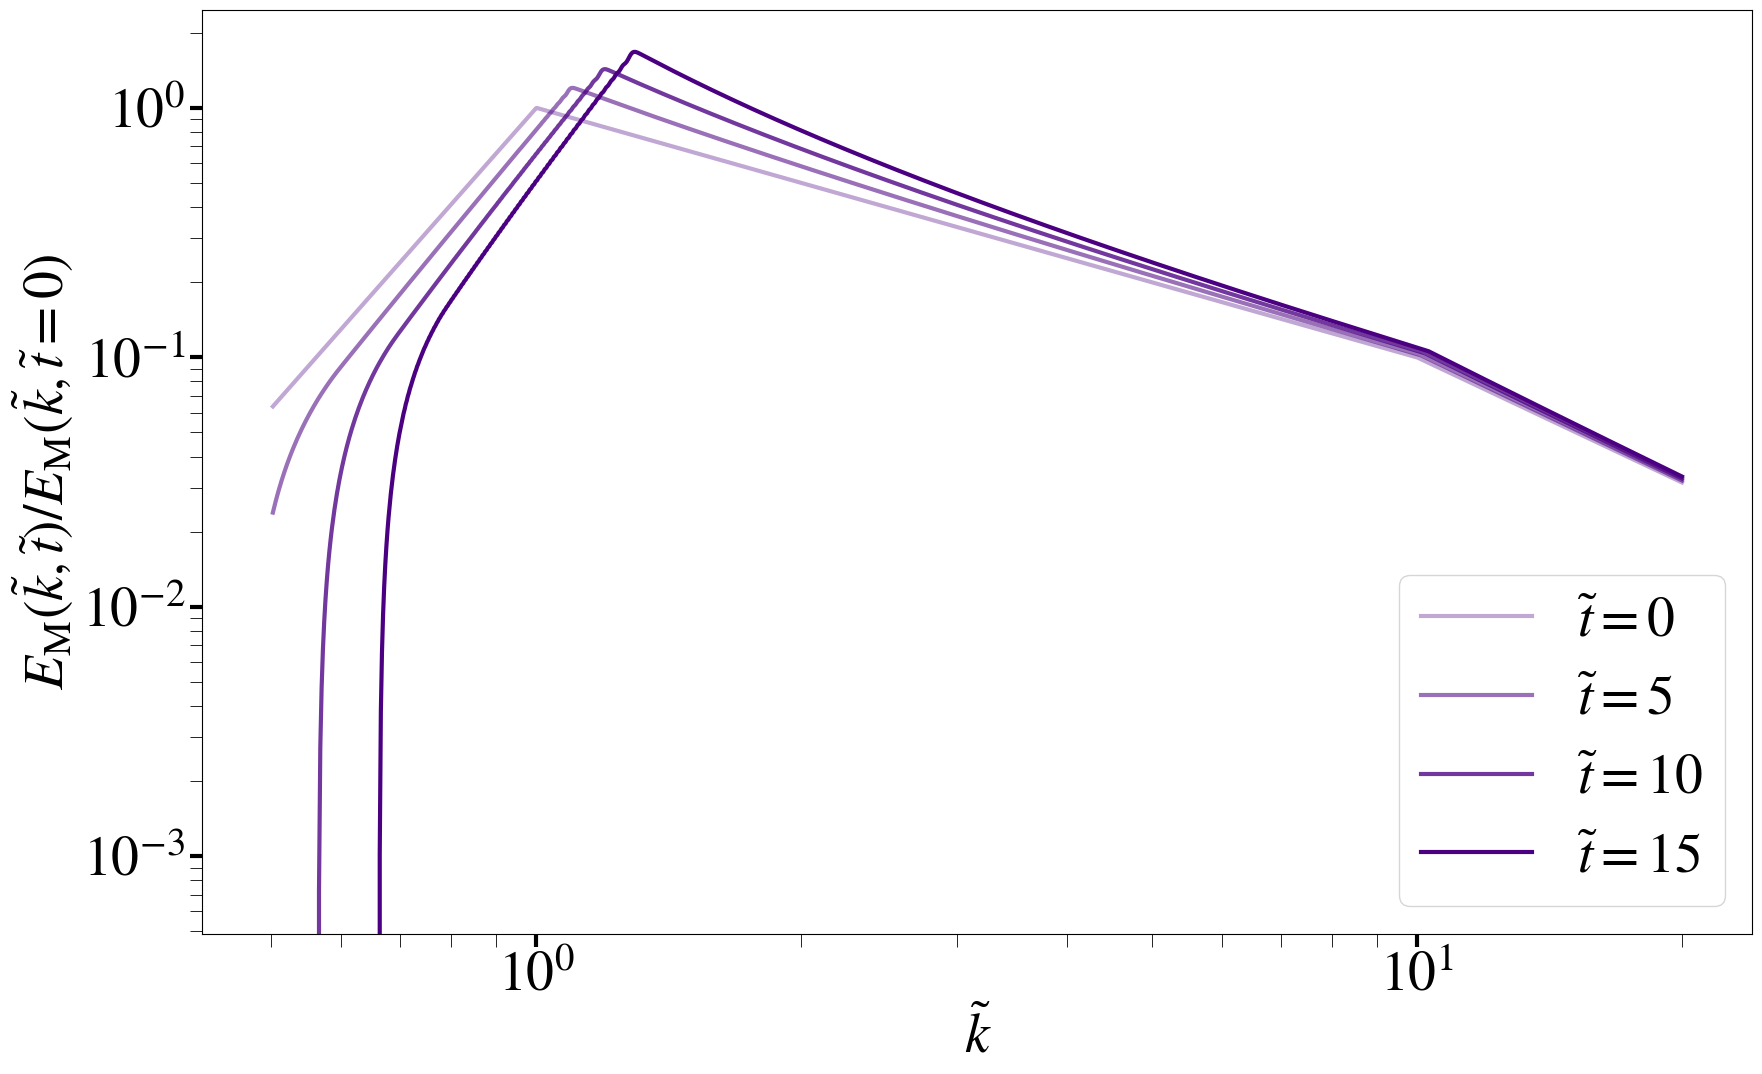

In [20]:
plt.figure(figsize=(20, 12))
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 40
plt.rcParams['mathtext.fontset'] = 'stix'
colors = ["indigo","blueviolet", "violet","palevioletred"]
index = 0
style ="solid"
alpha = 1

#times = [0,5,10,15]
#timesp = [r"$t = $"+ str(round(t_ff[int(time/dt)],1)) + r"$t_{\rm{ff}}$" for time in times]
times = [0, 2500, 5000, 7500]
timesp = [r"$\tilde{t} = $"+ str(int(time * dt)) for time in times]

alpha = 0.34
for time in times:
    plt.loglog(k,E[int(time),:],alpha = alpha,color=colors[0],linewidth=3)
    alpha += 0.22
    index+=1
legend = plt.legend(timesp) 
text_objects = legend.get_texts()


#plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)
plt.xlabel(r'$\tilde{k}$')
plt.ylabel(r'${E}_{\mathrm{M}}(\tilde{k}, \tilde{t})/{E}_{\mathrm{M}}(\tilde{k}, \tilde{t}=0)$')
plt.tick_params(which='minor', length=9)
plt.tick_params(which='major', length=9,width=3)
plt.savefig(f"fixedzeta.png")

plt.show()


## Changing Zeta

In [63]:
#changing zeta-0
#defined variables
Lk = 20    #max k
T = 0.20     #max time
Nk = 10000    
Nt = 10000
zetamax = 3  #Max zeta
dk = Lk / Nk  
dt = T / Nt        
k_j = 2    #Jean's wavenumber
zetaf = 0   #final zeta at k_j integration (ensure continuity)


aLst = [0.5,1]
for a in aLst:
    E = np.zeros((Nt, Nk))
    k = np.linspace(0.5, Lk, Nk)  

    #initial conditions
    count = 0
    for ki in k:
        if ki < 1:
            E[0,count] = ki**4
        elif ki<10:
            E[0,count] = ki**(-1)
        elif ki>= 10:
            E[0,count] =  (4.64)*ki**(-5/3)
        count+=1

    #integration loop
    for ti in range(0, Nt-1):
        for ki in range(0, Nk):
            
            #define zeta
            if k[ki] < k_j:
                zeta = np.tanh(k[ki])/(np.pi/2) * zetamax
                zetaf  = zeta 
            if k[ki] > k_j:
                zeta = (1 - np.tanh(a*(k[ki]-k_j)))* zetaf


            #integrate
            if ki == 0: #left boundary
                E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki]) / (0.5*dk) - (4 / k[ki]) * E[ti, ki]) 
            if 0<ki<Nk-1: 
                E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki-1]) / dk - (4 / k[ki]) * E[ti, ki])
            if ki == Nk-1: #right boundary
                E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki] - E[ti, ki-1]) / (0.5*dk) - (4 / k[ki]) * E[ti, ki])


    vmin, vmax = -0.1, 100000

    k_max = []
    for E_i in E:
        k_max.append(k[np.argmax(E_i)])
    t_ff = []
    for i in range(len(E)):
        t_ff.append( np.pi * i / (2 * np.sqrt(2) * np.arccos( 1/ k_max[i])))


    #times = [0,5,10,15]
    #timesp = [r"$t = $"+ str(round(t_ff[int(time/dt)],1)*dt) + r"$t_{\rm{ff}}$" for time in times]

    times = [0, 2500, 5000, 7500]
    timesp = [r"$\tilde{t} = $"+ str(int(time * dt)) for time in times]
    times= [0,0.05,0.1,0.15]
    plt.figure(figsize=(20, 12))
    plt.rcParams['font.family'] = 'STIXGeneral'
    plt.rcParams['font.size'] = 40
    plt.rcParams['mathtext.fontset'] = 'stix'
    colors = ["indigo","blueviolet", "violet","palevioletred"]
    index = 0
    style ="solid"
    alpha = 0.34
    for time in times:
        plt.loglog(k,E[int(time/dt),:],alpha = alpha,color=colors[0],linewidth=3, label = r"$\tilde{t} = $" + str(time))
        alpha += 0.22
        index+=1

    #plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)
    plt.xlabel(r'$\tilde{k}$')
    plt.ylabel(r'${E}_{\mathrm{M}}(\tilde{k}, \tilde{t})/{E}_{\mathrm{M}}(\tilde{k}, \tilde{t}=0)$')
    plt.tick_params(which='minor', length=9)
    plt.tick_params(which='major', length=9,width=3)
    plt.legend()
    plt.savefig(f"aeq{a}x100.png")
    #plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)
    plt.close()




## Zeta vs K

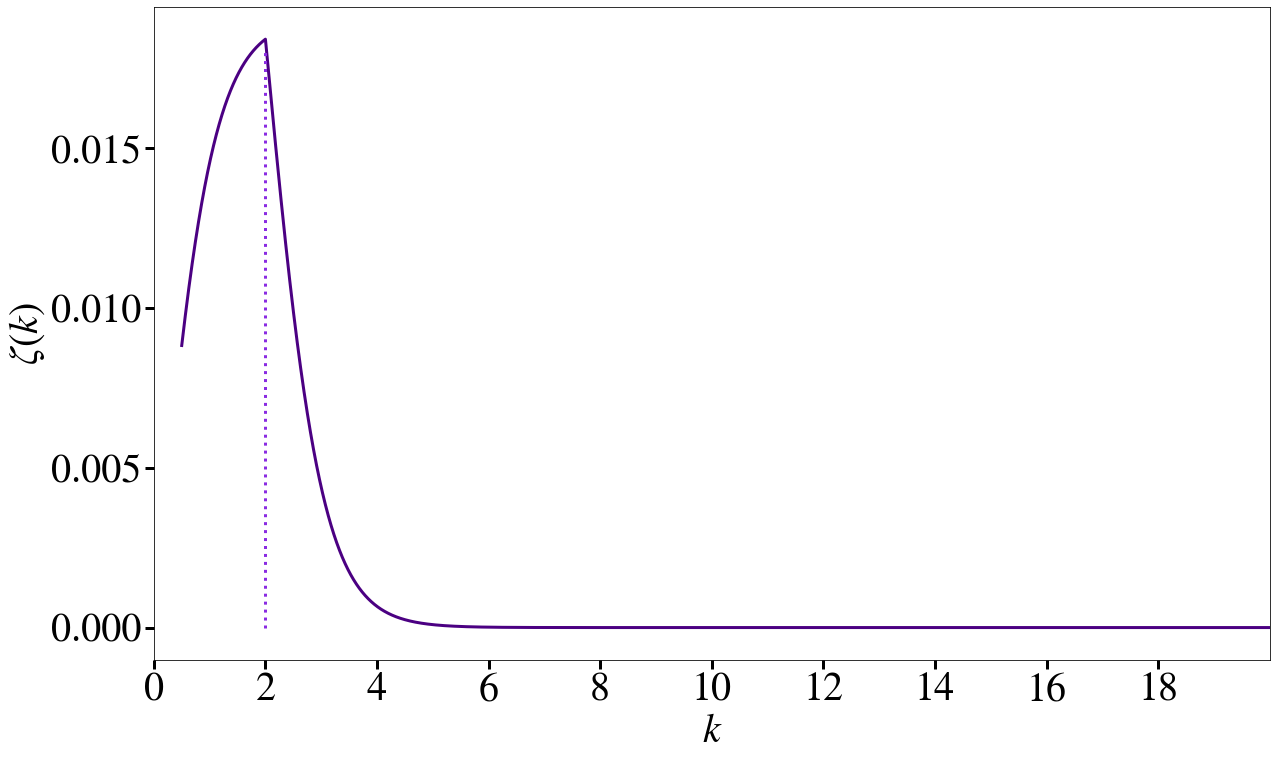

0.002 0.002


In [ ]:


#changing zeta-0
#defined variables
Lk = 20    #max k
T = 20     #max time
Nk = 10000    
Nt = 10000
zetamax = 0.03  #Max zeta
dk = Lk / Nk  
dt = T / Nt        
E = np.zeros((Nt, Nk))
k = np.linspace(0.5, Lk, Nk)  
k_j = 2     #Jean's wavenumber
zetaf = 0   #final zeta at k_j integration (ensure continuity)

zetas = list()
#initial conditions
count = 0
for ki in k:
    if ki < 1:
        E[0,count] = ki**4
    elif ki<10:
        E[0,count] = ki**(-1)
    elif ki>= 10:
        E[0,count] =  (4.64)*ki**(-5/3)
    count+=1

#integration loop

for ki in range(0, Nk):
    kloop = k[ki]
    #define zeta
    if kloop <= k_j:
        zeta = np.tanh(kloop)/(np.pi/2) * zetamax
        
        zetaf  = zeta 
    if kloop > k_j:
        zeta = (1 - np.tanh(1*(kloop-k_j)))* zetaf

    zetas.append(zeta)

plt.figure(figsize=(20, 12))
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 40
plt.rcParams['mathtext.fontset'] = 'stix'
colors = ["indigo","blueviolet", "violet","palevioletred"]
index = 0
style ="solid"
plt.plot(k,zetas,linestyle = style,color=colors[index],linewidth=3)
plt.vlines(x=2,ymin=0,ymax = 0.018,linestyle=':',linewidth = 3,color = "blueviolet")
plt.xlabel(r'$k$')
plt.ylabel(r'$\zeta(k)$')
plt.tick_params(which='minor', length=9)
plt.tick_params(which='major', length=9,width=3)
plt.xlim(k[0],20)
plt.ylim(-0.001,max(zetas)+0.001)
plt.xticks(np.arange(0,20,2))




#plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)


plt.show()


## Method of Characteristics

/var/folders/q4/08b64m4s5d11kb26pblcxpx80000gn/T/ipykernel_1189/1807304615.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  E[count_t,count_k] = initial((ki-zetamax*t)) * (ki/(ki-zetamax*t))**4
/var/folders/q4/08b64m4s5d11kb26pblcxpx80000gn/T/ipykernel_1189/1807304615.py:51: RuntimeWarning: invalid value encountered in scalar multiply
  E[count_t,count_k] = initial((ki-zetamax*t)) * (ki/(ki-zetamax*t))**4


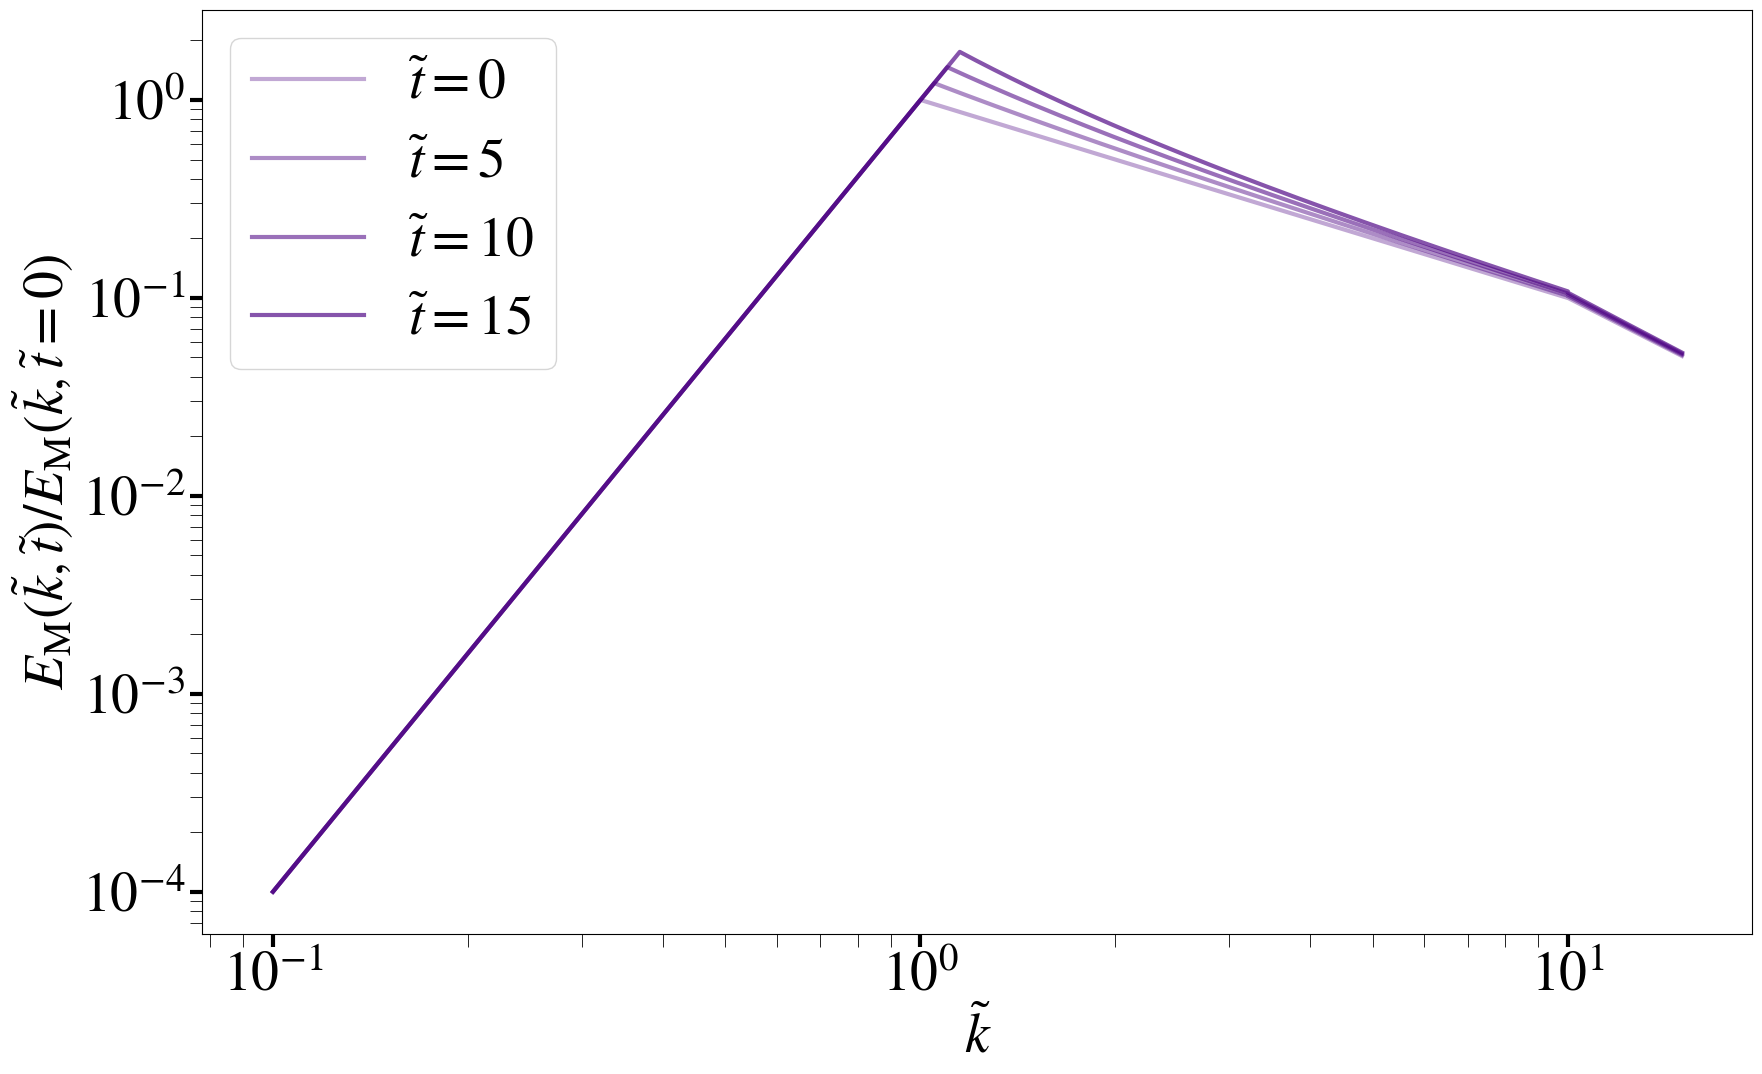

In [9]:
#method of charisteristics


#defined variables
zetamax = 0.01  #Max zeta
E = np.zeros((4,100000))
k = np.linspace(0.1,15,100000)
k_j = 3     #Jean's wavenumber
zetaf = 0   #final zeta at k_j integration (ensure continuity)

times = [0,5,10,15]
#initial conditions
count = 0
for ki in k:
    if ki < 1:
        E[0,count] = ki**4
    elif ki<10:
        E[0,count] = ki**(-1)
    elif ki>= 10:
        E[0,count] =  (10**(2/3))*ki**(-5/3)
    count+=1

def zeta(ki):
    if k[ki] < k_j:
        zeta = np.tanh(k[ki])/(np.pi/2) * zetamax
        zetaf  = zeta 
        return zeta
    if int(k[ki]) == k_j:
        return zetaf
    if k[ki] > k_j:
        zeta = (1 - np.tanh((k[ki]-k_j)))* zetaf
        return zeta
        
def initial(k_i):
    if k_i < 1:
        return k_i**4
    elif ki<10:
        return k_i**(-1)
    elif ki >= 10:
        return (4.64)*ki**(-5/3)
    
count_t = 0
for t in times:
    count_k = 0
    for ki in k:
        #E[count_t,count_k] = E[0,int(count_k-zetamax*t)] * (ki**4)/(ki-zetamax*t)**4
        #if ki < k_j:
            #E[count_t,count_k] = initial((ki-zeta(int(ki))*t)) * ((ki)/(np.arcsinh(np.sinh(ki)*np.exp(-np.pi/2*zeta(int(ki))*t))))**4
        #else: 
            #E[count_t,count_k] = initial((ki-zeta(int(ki))*t)) * ((ki)/(ki - zeta(int(ki))*t))**4  
        E[count_t,count_k] = initial((ki-zetamax*t)) * (ki/(ki-zetamax*t))**4

        count_k +=1
    count_t +=1



plt.figure(figsize=(20, 12))
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 40
plt.rcParams['mathtext.fontset'] = 'stix'
colors = ["indigo","blueviolet", "violet","palevioletred"]
index = 0
style ="solid"
alpha = 0.34
timesp = [0,5,10,15]

for i in range(4):
    plt.loglog(k,E[i,:],alpha = alpha,color=colors[0],linewidth=3, label = r"$\tilde{t} = $" + str(timesp[i]))
    alpha += 0.11
    index+=1
plt.legend() 

#plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)
plt.xlabel(r'$\tilde{k}$')
plt.ylabel(r'${E}_{\mathrm{M}}(\tilde{k}, \tilde{t})/{E}_{\mathrm{M}}(\tilde{k}, \tilde{t}=0)$')

plt.tick_params(which='minor', length=9)
plt.tick_params(which='major', length=9,width=3)



    
        


## Simulation Comparison

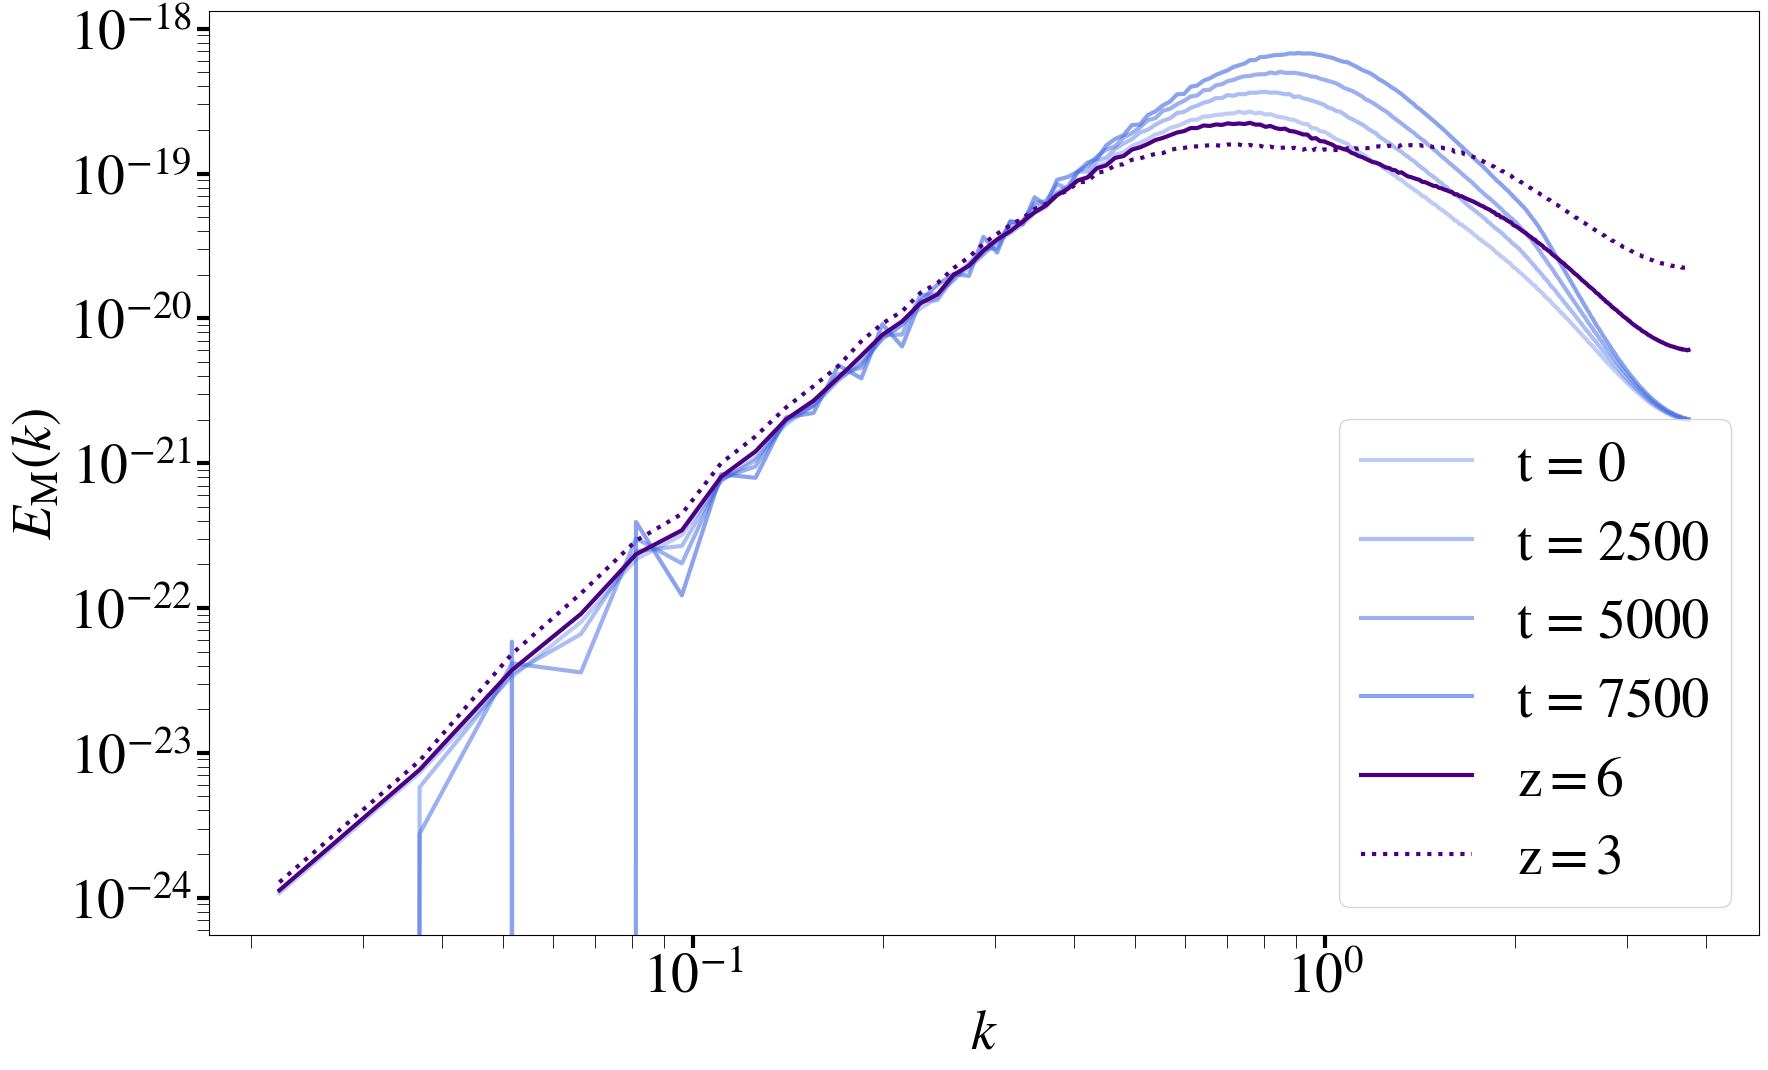

In [42]:

#new boundary conditions
def load_txt_to_columns(file_path):
    data = np.loadtxt(file_path, delimiter='\t') 
    column1, column2 = data[:, 0], data[:, 1]  
    return column1, column2


file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_10.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k = 10**np.array(column1)

initial_E = 10**np.array(column2)


#changing zeta-0
#defined variables
Lk = 20    #max k
T = 40     #max time
Nk = len(column1)    
Nt = 20000
zetamax = 0.03  #Max zeta
dk = Lk / Nk  
dt = T / Nt        
E = np.zeros((Nt, Nk))
k = initial_k
k_j = 2     #Jean's wavenumber
zetaf = 0   #final zeta at k_j integration (ensure continuity)

E[0,:] = initial_E

#integration loop
for ti in range(0, Nt-1):
    for ki in range(len(initial_k)):
        
        #define zeta
        if initial_k[ki] < k_j:
            zeta = np.tanh(k[ki])/(np.pi/2) * zetamax
            zetaf  = zeta 
        if initial_k[ki] > k_j:
            zeta = (1 - np.tanh(1*(k[ki]-k_j)))* zetaf


        #integrate
        if ki == 0: #left boundary
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki]) / (0.5*(initial_k[ki+1]-initial_k[ki])) - (4 / initial_k[ki]) * E[ti, ki]) 
        if 0<ki<Nk-1: 
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki-1]) / (initial_k[ki+1]-initial_k[ki-1]) - (4 / initial_k[ki]) * E[ti, ki])
        if ki == Nk-1: #right boundary
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki] - E[ti, ki-1]) / (0.5*(initial_k[ki]-initial_k[ki-1])) - (4 / initial_k[ki]) * E[ti, ki])


vmin, vmax = -0.1, 100000

plt.figure(figsize=(20, 12))

plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 40
plt.rcParams['mathtext.fontset'] = 'stix'
index = 0
style ="solid"
alpha = 0.34
for time in times:
    plt.loglog(k,E[int(time/dt),:],alpha = alpha,color = "royalblue",linewidth=3, label = f"t = {int(time/dt)}")
    alpha += 0.09
    index+=1

file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_6.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k_6 = 10**np.array(column1)

initial_E_6 = 10**np.array(column2)

file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_3.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k_3 = 10**np.array(column1)

initial_E_3 = 10**np.array(column2)

plt.loglog(initial_k_6,initial_E_6,label = r"$\mathrm{z} = 6$",linewidth=3, c = "indigo")
plt.loglog(initial_k_3,initial_E_3,label = r"$\mathrm{z} = 3$",linewidth=3,linestyle = ":", c="indigo")


#plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)
plt.xlabel(r'$k$')
plt.ylabel(r'$E_{\mathrm{M}}(k)$')
plt.tick_params(which='minor', length=9)
plt.tick_params(which='major', length=9,width=3)

plt.legend(loc = "lower right")
plt.show()





In [69]:
def load_txt_to_columns(file_path):
    data = np.loadtxt(file_path, delimiter='\t') 
    column1, column2 = data[:, 0], data[:, 1]  
    return column1, column2


cases = [["scale-inv","teal"],["uniform","saddlebrown"],["helical","olive"],["non-helical","cornflowerblue"]]

#defined variables
Lk = 20    #max k
T = 40     #max time
Nt = 20000
zetamax = 3  #Max zeta
k_j = 2     #Jean's wavenumber
zetaf = 0   #final zeta at k_j integration (ensure continuity)

ovrlay = True

for case,color in cases:
    file_path = f"/Users/mollyabramson/Downloads/DataForMolly/{case}/EBVsk_z_10.txt"  
    column1, column2 = load_txt_to_columns(file_path)
    initial_k = 10**np.array(column1)
    initial_E = 10**np.array(column2)
    Nk = len(initial_k)
    dk = Lk / Nk  
    dt = T / Nt     
    Nk = len(column1)   
    E = np.zeros((Nt, Nk))
 
    E[0,:] = initial_E
    k = initial_k

    for ti in range(0, Nt-1):
        for ki in range(len(initial_k)):
            
            #define zeta
            if initial_k[ki] < k_j:
                zeta = np.tanh(k[ki])/(np.pi/2) * zetamax
                zetaf  = zeta 
            if initial_k[ki] > k_j:
                zeta = (1 - np.tanh(1*(k[ki]-k_j)))* zetaf


            #integrate
            if ki == 0: #left boundary
                E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki]) / (0.5*(initial_k[ki+1]-initial_k[ki])) - (4 / initial_k[ki]) * E[ti, ki]) 
            if 0<ki<Nk-1: 
                E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki-1]) / (initial_k[ki+1]-initial_k[ki-1]) - (4 / initial_k[ki]) * E[ti, ki])
            if ki == Nk-1: #right boundary
                E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki] - E[ti, ki-1]) / (0.5*(initial_k[ki]-initial_k[ki-1])) - (4 / initial_k[ki]) * E[ti, ki])


    vmin, vmax = -0.1, 100000
    plt.figure(figsize=(20, 12))
    fig, ax = plt.subplots(figsize=(20,12))

    plt.rcParams['font.family'] = 'STIXGeneral'
    plt.rcParams['font.size'] = 40
    plt.rcParams['mathtext.fontset'] = 'stix'
    index = 0
    style ="solid"
    alpha = 0.34
    times = [0,5,10,15]
    if zetamax == 3:
        times = [t/100 for t in times]
    for time in times:
        plt.loglog(k,E[int(time/dt),:],alpha = alpha,color = color,linewidth=3, label = r"$\tilde{t} = $" + str((time)))
        alpha += 0.22
        index+=1
        
    if ovrlay:
        file_path = f"/Users/mollyabramson/Downloads/DataForMolly/{case}/EBVsk_z_6.txt"  
        column1, column2 = load_txt_to_columns(file_path)

        initial_k_6 = 10**np.array(column1)

        initial_E_6 = 10**np.array(column2)

        file_path = f"/Users/mollyabramson/Downloads/DataForMolly/{case}/EBVsk_z_3.txt"  
        column1, column2 = load_txt_to_columns(file_path)

        initial_k_3 = 10**np.array(column1)

        initial_E_3 = 10**np.array(column2)

        file_path = f"/Users/mollyabramson/Downloads/DataForMolly/{case}/EBVsk_z_2.txt"  
        column1, column2 = load_txt_to_columns(file_path)

        initial_k_2 = 10**np.array(column1)

        initial_E_2 = 10**np.array(column2)

        plt.loglog(initial_k_6,initial_E_6,label = r"$z = 6$",linewidth=3, c = "indigo", linestyle = "--")
        plt.loglog(initial_k_3,initial_E_3,label = r"$z = 3$",linewidth=3,linestyle = "-.", c="indigo")
        plt.loglog(initial_k_2,initial_E_2,label = r"$z = 2$",linewidth=3,linestyle = ":", c="indigo")




    
    #plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)
    plt.xlabel(r'$k[h \cdot \mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$E_{\mathrm{M}}({k})[\mathrm{Mpc \cdot G^2}\cdot h^{-1}]$')
    plt.tick_params(which='minor', length=9)
    plt.tick_params(which='major', length=9,width=3)
    ax.text(0.95, 0.95, r"$\zeta_0=$"+ str(zetamax), 
        transform=ax.transAxes, 
        ha='right', 
        va='top')

    plt.legend()
    if ovrlay:
        
        if zetamax ==3:
            plt.savefig(f'{case}_overlayx100.png')

        else:
            plt.savefig(f'{case}_overlay.png')

    else:
        if zetamax==3:
            plt.savefig(f'{case}x100.png')
        else:
            plt.savefig(f'{case}.png')
    plt.close()



<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

## Implicit Method

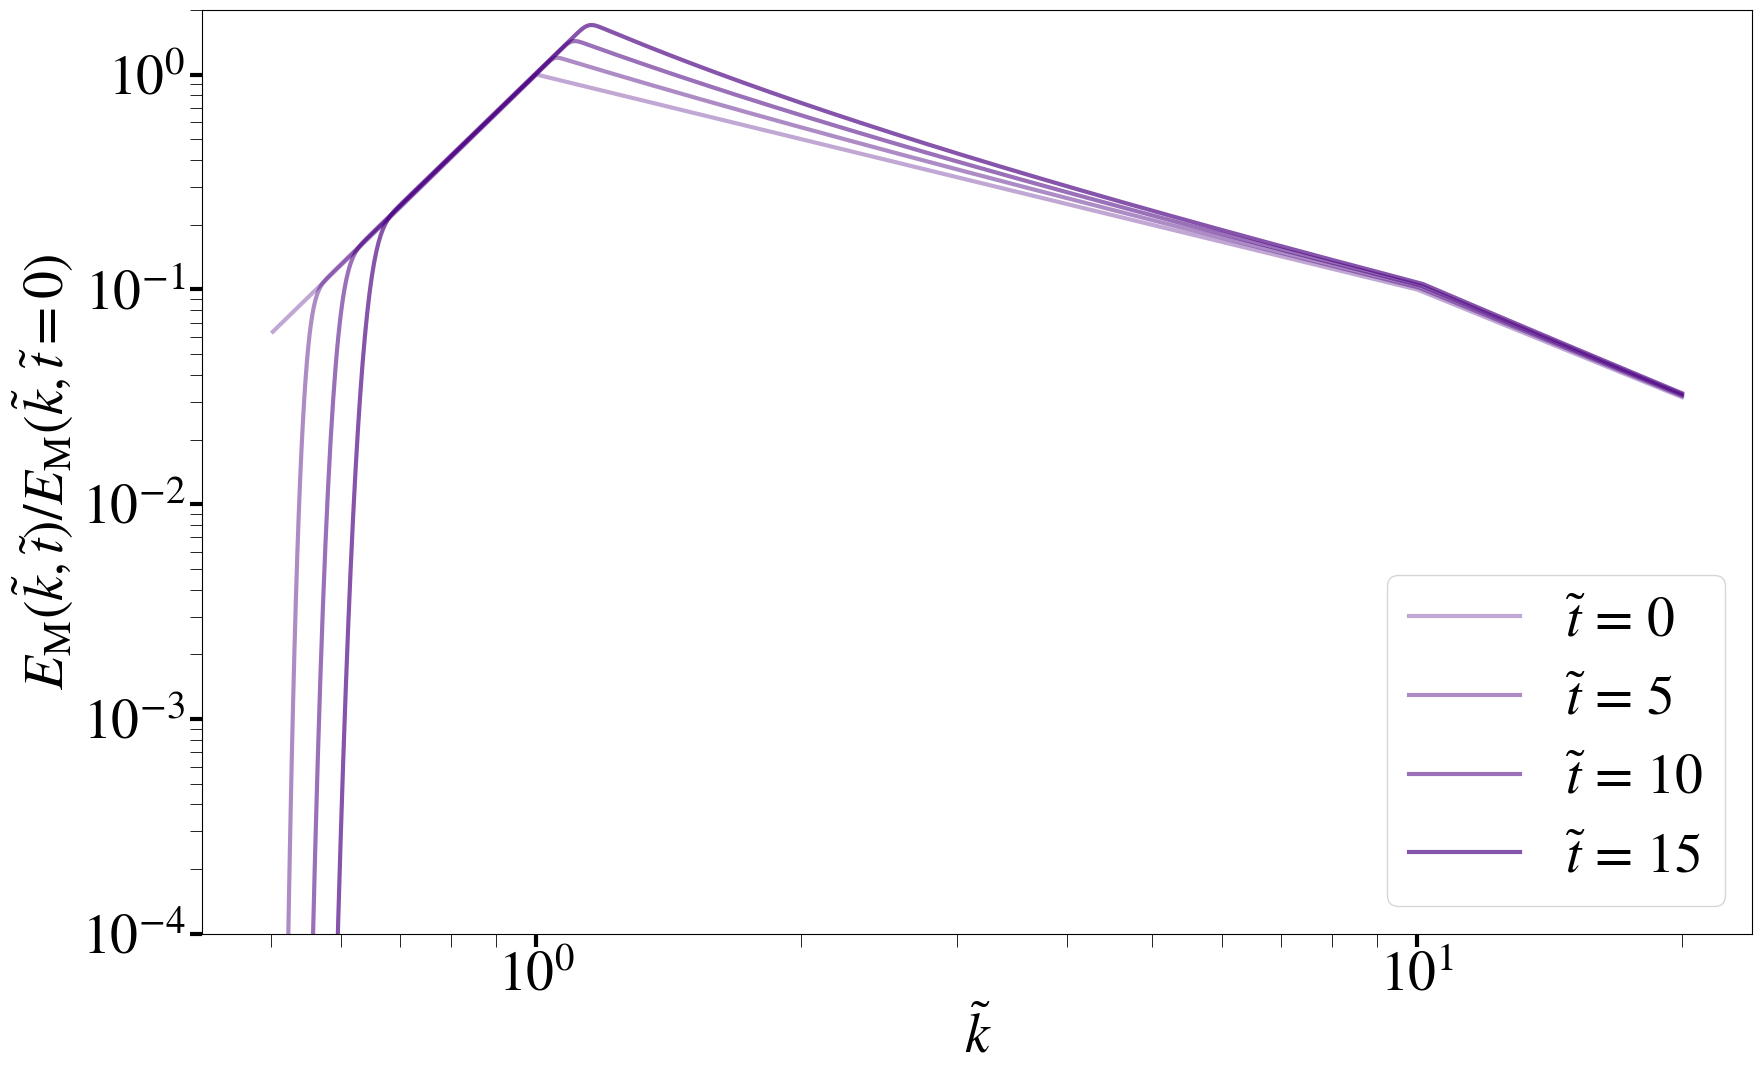

In [15]:

# Initial Parameters
K = 20
T = 20
Nk = 10000
Nt = 10000
dk = K / Nk
dt = T / Nt
zeta_0 = 0.01

k = np.linspace(dk + 0.5, Lk, Nk)  
E = np.zeros((Nt, Nk))

# Initial Conditions
count = 0
for ki in k:
    if ki < 1:
        E[0,count] = ki**4
    elif ki<10:
        E[0,count] = ki**(-1)
    elif ki>= 10:
        E[0,count] =  (4.64)*ki**(-5/3)
    count+=1


main = np.zeros_like(k) # Main diagonal of banded matrix
lower = np.zeros_like(k) # Lower Diagnoal of banded matrix

# Updated main and lower diagonals
for i in range(len(k)):
    lambda_i = zeta_0 * dt / dk
    main[i] = 1 + lambda_i - 4 * zeta_0 * dt / k[i]
    lower[i] = - lambda_i
    if i ==  len(k):
        lower[i] = 0

# Banded Matrix
bandedmatrix = np.zeros((2,Nk)) 
bandedmatrix[0, :] = lower 
bandedmatrix[1, :] = main        

# Solve
for n in range(Nt-1):
    E[n+1,:] = solve_banded((1, 0), np.vstack([main, lower]), E[n,:]) # one non zero lower diagonal, zero non zero upper diagonal

# Plot parameters
plt.figure(figsize=(20, 12))
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 40
plt.rcParams['mathtext.fontset'] = 'stix'
index = 0
style ="solid"
times = [0,5,10,15]
timesp = [r"$\tilde{t}$ = "+ str(time) for time in times]
alpha = 0.34

for time in times:
    plt.loglog(k,E[int(time/dt),:],linestyle = style,color="indigo",linewidth=3, alpha =alpha)
    index+=1
    alpha+=0.11
plt.legend(timesp) 
plt.xlabel(r'$\tilde{k}$')
plt.ylabel(r'${E}_{\mathrm{M}}(\tilde{k}, \tilde{t})/{E}_{\mathrm{M}}(\tilde{k}, \tilde{t}=0)$')
plt.ylim(1e-4,2)
plt.tick_params(which='minor', length=9)
plt.tick_params(which='major', length=9,width=3)
plt.show()

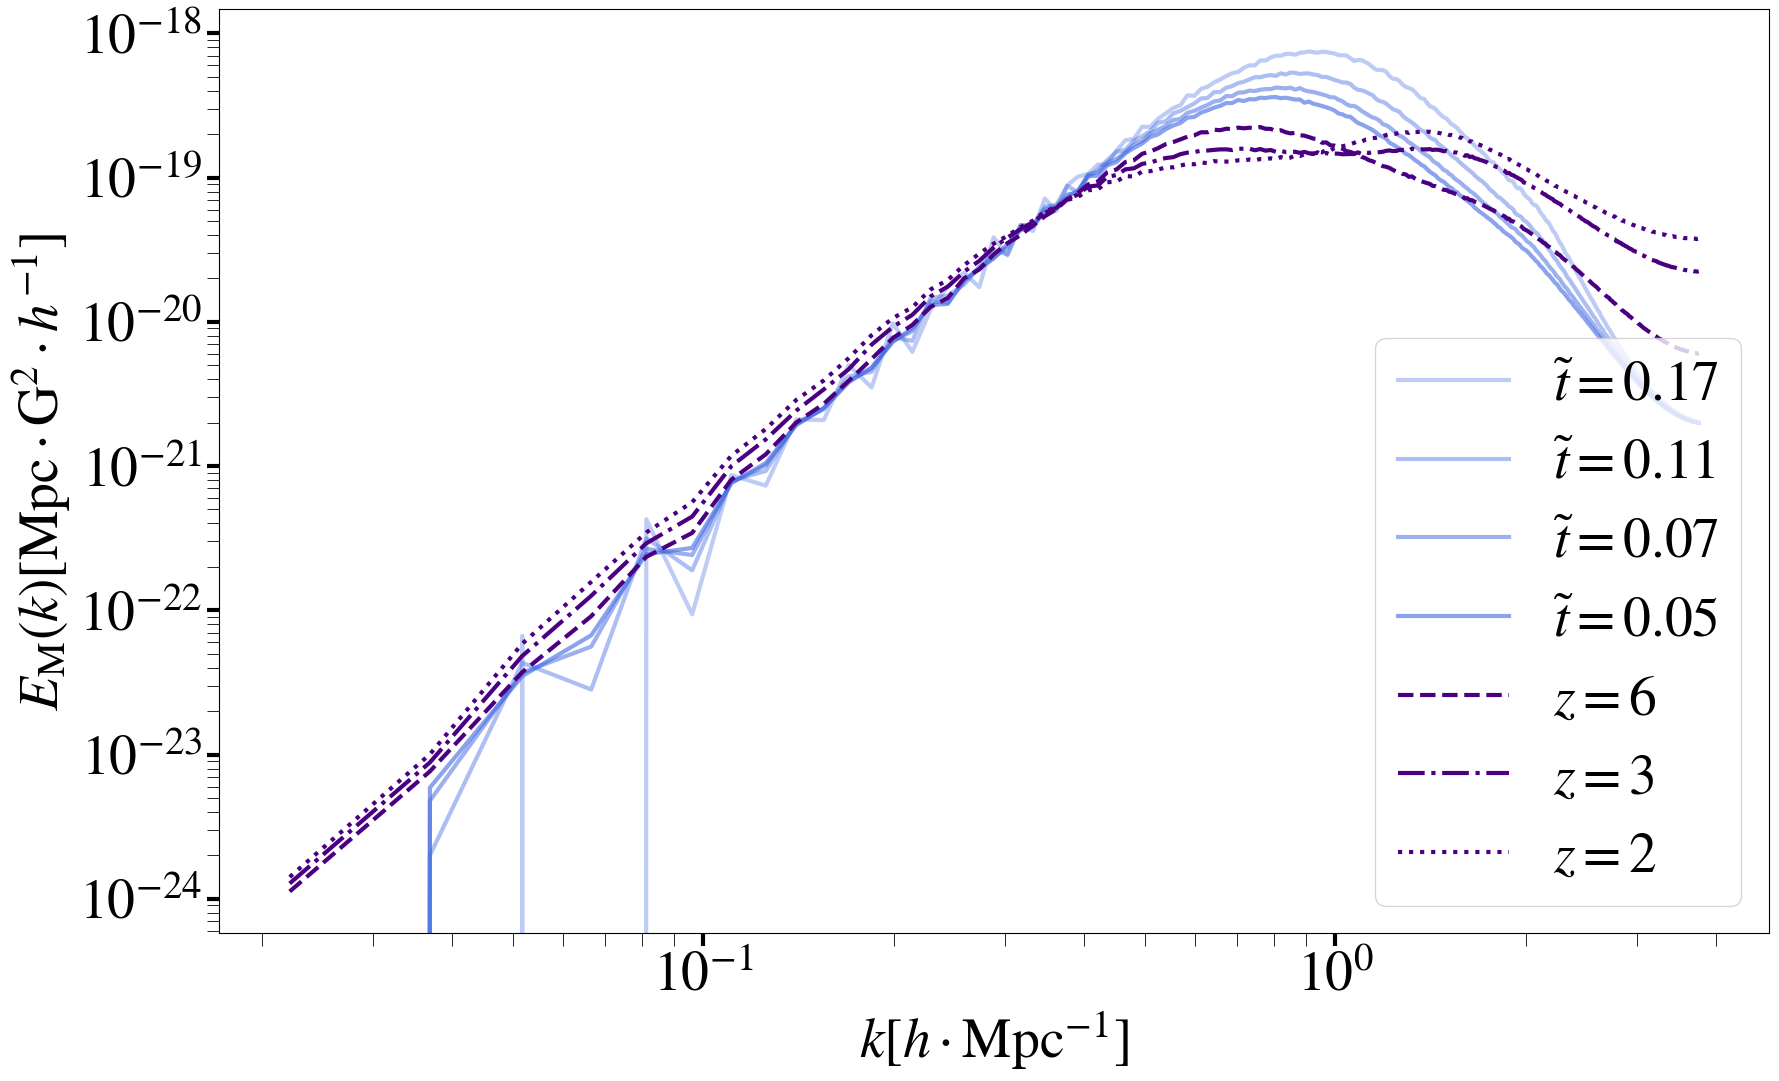

In [45]:
file_h5 = h5py.File("data_Jenny.h5")
dynTime = file_h5["Time_Gyr"][:]/file_h5["Time_dynamical_Gyr"][:]

#new boundary conditions
def load_txt_to_columns(file_path):
    data = np.loadtxt(file_path, delimiter='\t') 
    column1, column2 = data[:, 0], data[:, 1]  
    return column1, column2


file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_10.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k = 10**np.array(column1)

initial_E = 10**np.array(column2)


#changing zeta-0
#defined variables
Lk = 20    #max k
T = 40     #max time
Nk = len(column1)    
Nt = 20000
zetamax = 3  #Max zeta
dk = Lk / Nk  
dt = T / Nt        
E = np.zeros((Nt, Nk))
k = initial_k
k_j = 2     #Jean's wavenumber
zetaf = 0   #final zeta at k_j integration (ensure continuity)


trueTime = np.arange(0,T,dt)
closest_idx = np.argmin(np.abs(trueTime[:, None] - dynTime[None, :]), axis=0)

timesFind = trueTime[closest_idx]
idx = np.linspace(0, len(timesFind) - 1, 4, dtype=int)
sample = timesFind[idx]


E[0,:] = initial_E

#integration loop
for ti in range(0, Nt-1):
    for ki in range(len(initial_k)):
        
        #define zeta
        if initial_k[ki] < k_j:
            zeta = np.tanh(k[ki])/(np.pi/2) * zetamax
            zetaf  = zeta 
        if initial_k[ki] > k_j:
            zeta = (1 - np.tanh(1*(k[ki]-k_j)))* zetaf


        #integrate
        if ki == 0: #left boundary
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki]) / (0.5*(initial_k[ki+1]-initial_k[ki])) - (4 / initial_k[ki]) * E[ti, ki]) 
        if 0<ki<Nk-1: 
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki+1] - E[ti, ki-1]) / (initial_k[ki+1]-initial_k[ki-1]) - (4 / initial_k[ki]) * E[ti, ki])
        if ki == Nk-1: #right boundary
            E[ti+1, ki] = E[ti, ki] - dt * zeta*((E[ti, ki] - E[ti, ki-1]) / (0.5*(initial_k[ki]-initial_k[ki-1])) - (4 / initial_k[ki]) * E[ti, ki])


vmin, vmax = -0.1, 100000

plt.figure(figsize=(20, 12))

plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 40
plt.rcParams['mathtext.fontset'] = 'stix'
index = 0
style ="solid"
alpha = 0.34
for time in sample:
    plt.loglog(k,E[int(time/dt),:],alpha = alpha,color = "royalblue",linewidth=3, label = r"$\tilde{t} = $" + f"{round(time,2)}")
    alpha += 0.09
    index+=1

file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_6.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k_6 = 10**np.array(column1)

initial_E_6 = 10**np.array(column2)

file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_3.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k_3 = 10**np.array(column1)

initial_E_3 = 10**np.array(column2)


file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_2.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k_2 = 10**np.array(column1)

initial_E_2 = 10**np.array(column2)

file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_1.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k_1 = 10**np.array(column1)

initial_E_1 = 10**np.array(column2)


file_path = "/Users/mollyabramson/Downloads/DataForMolly/non-helical/EBVsk_z_0.1.txt"  
column1, column2 = load_txt_to_columns(file_path)

initial_k_01 = 10**np.array(column1)

initial_E_01 = 10**np.array(column2)






plt.loglog(initial_k_6,initial_E_6,label = r"${z} = 6$",linewidth=3, c = "indigo",linestyle = "--")
plt.loglog(initial_k_3,initial_E_3,label = r"${z} = 3$",linewidth=3,linestyle = "-.", c="indigo")
plt.loglog(initial_k_2,initial_E_2,label = r"${z} = 2$",linewidth=3, c = "indigo",linestyle = ":")


#plt.imshow(E, aspect = "auto", extent=[k[0], k[-1], 0, T], cmap='hot',vmin=vmin,vmax=vmax)
plt.xlabel(r'$k[h \cdot \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$E_{\mathrm{M}}({k})[\mathrm{Mpc \cdot G^2}\cdot h^{-1}]$')
plt.tick_params(which='minor', length=9)
plt.tick_params(which='major', length=9,width=3)

plt.legend(loc = "lower right")
plt.show()




